In [1]:
# Automobile Price Analysis & Predictive Insights

### Data Analytics Portfolio Project

**Tools:** Python | Pandas | Matplotlib | Seaborn | Jupyter Notebook

**Dataset:** Automobile Dataset

**Objective:** Analyze automobile characteristics and identify the major factors associated with vehicle pricing, performance, and fuel efficiency.

SyntaxError: invalid syntax (741618596.py, line 5)

In [ ]:
## 1. Project Objective

The objective of this project is to analyze automobile data and identify
patterns and relationships between vehicle characteristics, pricing,
performance, fuel efficiency, brand, body style, fuel type, and drive wheels.

### Key Questions

- Which vehicle characteristics are most strongly associated with price?
- How does automobile pricing vary across brands?
- How does fuel type affect price and fuel efficiency?
- How does body style relate to vehicle price?
- How does drive-wheel configuration relate to price?
- What is the relationship between engine size, horsepower, and MPG?
- Which vehicles have the highest prices?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("Automobile_data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 205
Columns: 15


In [4]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,?,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450


In [5]:
df.shape

(205, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   body-style         205 non-null    str    
 5   drive-wheels       205 non-null    str    
 6   engine-location    205 non-null    str    
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    str    
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    str    
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(2), int64(5), str(8)
memory usage: 24.2 KB


In [7]:
df.describe()

,symboling,width,height,engine-size,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,65.907805,53.724878,126.907317,25.219512,30.751220,13227.478049
std,1.245307,2.145204,2.443522,41.642693,6.542142,6.886443,7902.651615
min,-2.000000,60.300000,47.800000,61.000000,13.000000,16.000000,5118.000000
25%,0.000000,64.100000,52.000000,97.000000,19.000000,25.000000,7788.000000
50%,1.000000,65.500000,54.100000,120.000000,24.000000,30.000000,10345.000000
75%,2.000000,66.900000,55.500000,141.000000,30.000000,34.000000,16500.000000
max,3.000000,72.300000,59.800000,326.000000,49.000000,54.000000,45400.000000


In [ ]:
### Initial Dataset Observations

The dataset contains 205 automobile records and 15 variables covering
vehicle specifications, engine characteristics, fuel efficiency,
drive configuration, and price.

In [8]:
# Replace ? with missing values
df = df.replace("?", pd.NA)

# Convert numerical columns
df["normalized-losses"] = pd.to_numeric(
    df["normalized-losses"],
    errors="coerce"
)

df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

# Fill missing numerical values using median
df["normalized-losses"] = df["normalized-losses"].fillna(
    df["normalized-losses"].median()
)

df["horsepower"] = df["horsepower"].fillna(
    df["horsepower"].median()
)

print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


In [ ]:
### Data Cleaning Summary

- Missing values represented by `?` were converted to null values.
- Numerical fields were converted to appropriate numerical data types.
- Missing numerical values were replaced using the median.
- Duplicate records were checked.
- No duplicate records remained after validation.

In [9]:
numeric_columns = [
    "width",
    "height",
    "engine-size",
    "horsepower",
    "city-mpg",
    "highway-mpg",
    "price"
]

correlation = df[numeric_columns].corr()

correlation

,width,height,engine-size,horsepower,city-mpg,highway-mpg,price
width,1.000000,0.279210,0.735433,0.641337,-0.642704,-0.677218,0.718253
height,0.279210,1.000000,0.067149,-0.109286,-0.048640,-0.107358,0.132444
engine-size,0.735433,0.067149,1.000000,0.810216,-0.653658,-0.677470,0.852995
horsepower,0.641337,-0.109286,0.810216,1.000000,-0.802170,-0.770780,0.747445
city-mpg,-0.642704,-0.048640,-0.653658,-0.802170,1.000000,0.971337,-0.654611
highway-mpg,-0.677218,-0.107358,-0.677470,-0.770780,0.971337,1.000000,-0.679048
price,0.718253,0.132444,0.852995,0.747445,-0.654611,-0.679048,1.000000


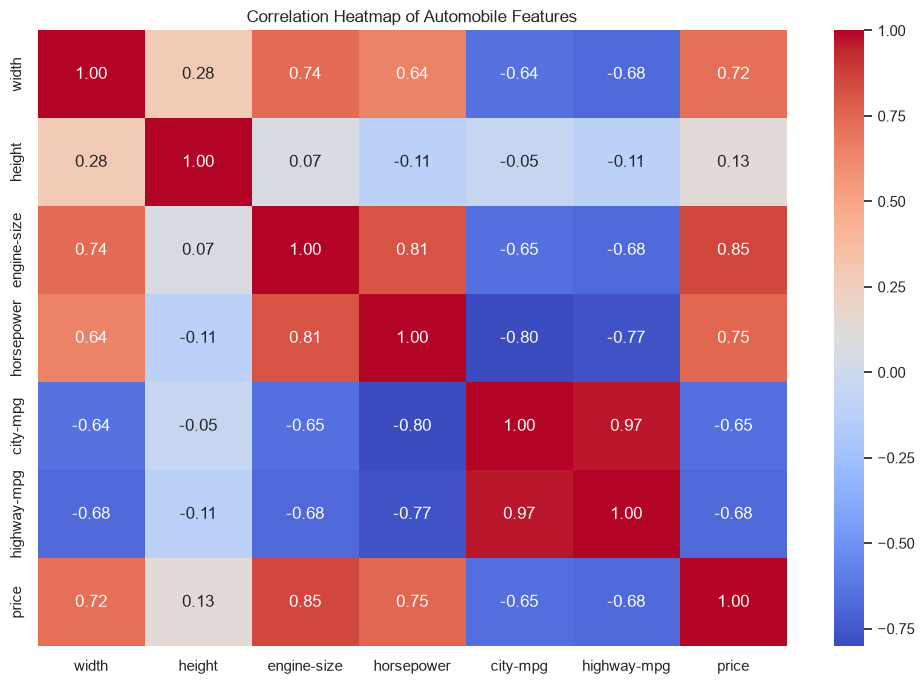

In [10]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Automobile Features")
plt.tight_layout()
plt.show()

In [ ]:
### Key Correlation Findings

Engine size has the strongest positive relationship with automobile price
(r = 0.853), followed by horsepower (r = 0.747) and vehicle width
(r = 0.718).

City MPG and highway MPG have negative relationships with price.

In [11]:
brand_price = (
    df.groupby("make")["price"]
      .mean()
      .sort_values(ascending=False)
)

print(brand_price)

make
jaguar           34600.000000
mercedes-benz    33647.000000
porsche          27520.400000
bmw              26118.750000
volvo            18063.181818
audi             17022.142857
mercury          16503.000000
alfa-romero      15498.333333
peugot           15489.090909
saab             15223.333333
isuzu            12708.250000
mazda            10652.882353
nissan           10415.666667
volkswagen       10077.500000
toyota            9885.812500
renault           9595.000000
mitsubishi        9239.769231
subaru            8541.250000
honda             8184.692308
plymouth          7963.428571
dodge             7875.444444
chevrolet         6007.000000
Name: price, dtype: float64


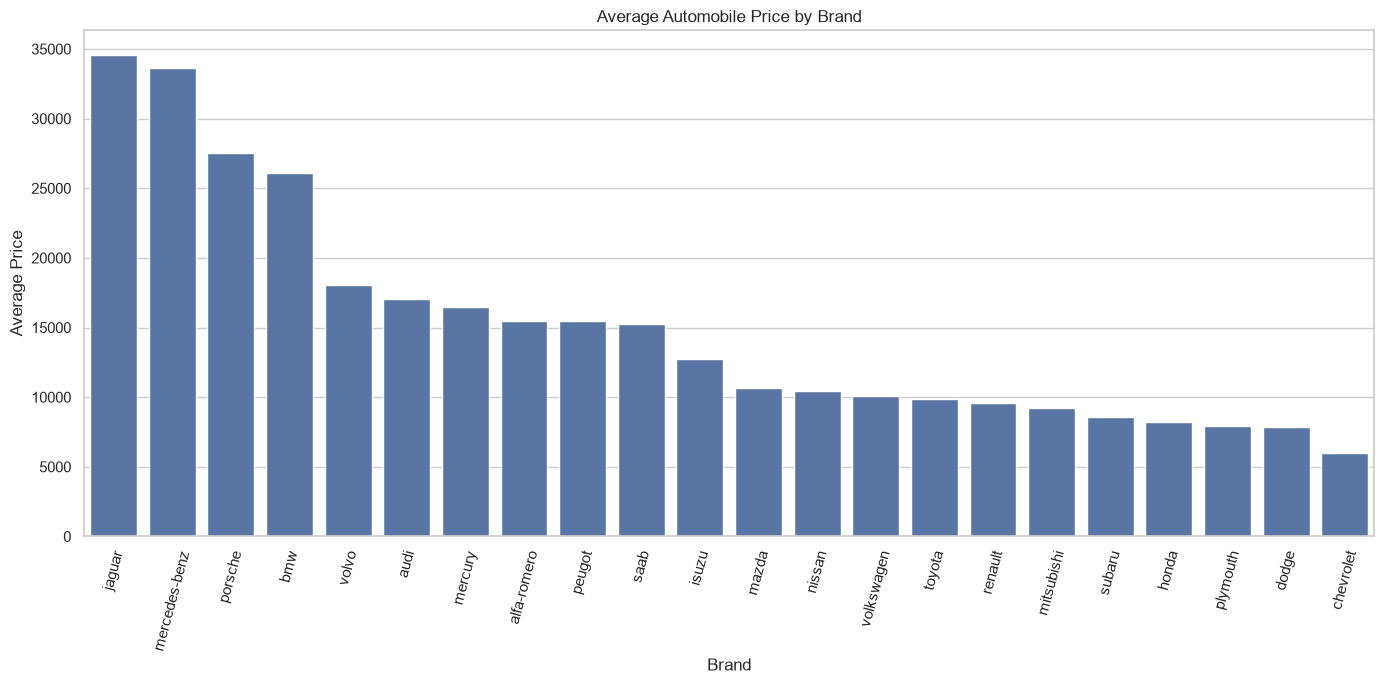

In [12]:
plt.figure(figsize=(14, 7))

sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.title("Average Automobile Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [ ]:
### Brand Analysis

Average automobile prices vary substantially across brands.

Jaguar has the highest average price in the dataset, while Chevrolet has
the lowest average price.

In [13]:
fuel_summary = df.groupby("fuel-type").agg(
    vehicle_count=("price", "count"),
    average_price=("price", "mean"),
    average_city_mpg=("city-mpg", "mean"),
    average_highway_mpg=("highway-mpg", "mean")
)

fuel_summary

,vehicle_count,average_price,average_city_mpg,average_highway_mpg
fuel-type,,,,
diesel,20,15838.150000,30.30000,34.750000
gas,185,12945.243243,24.67027,30.318919


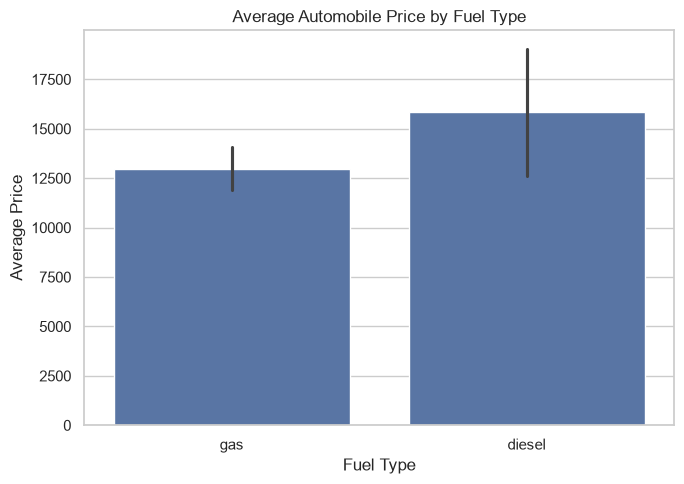

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="fuel-type",
    y="price"
)

plt.title("Average Automobile Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

In [ ]:
### Fuel Type Findings

The dataset contains 185 gas vehicles and 20 diesel vehicles.

Diesel vehicles have a higher average price and higher average city and
highway MPG than gas vehicles in this dataset.

In [15]:
body_price = (
    df.groupby("body-style")["price"]
      .mean()
      .sort_values(ascending=False)
)

print(body_price)

body-style
hardtop        22208.500000
convertible    21890.500000
sedan          14502.260417
wagon          12371.960000
hatchback      10015.800000
Name: price, dtype: float64


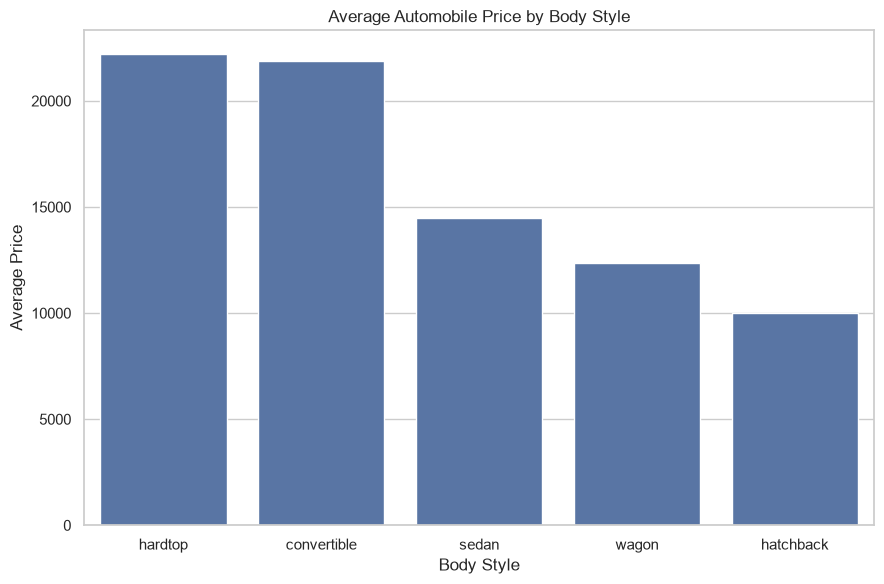

In [16]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=body_price.index,
    y=body_price.values
)

plt.title("Average Automobile Price by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

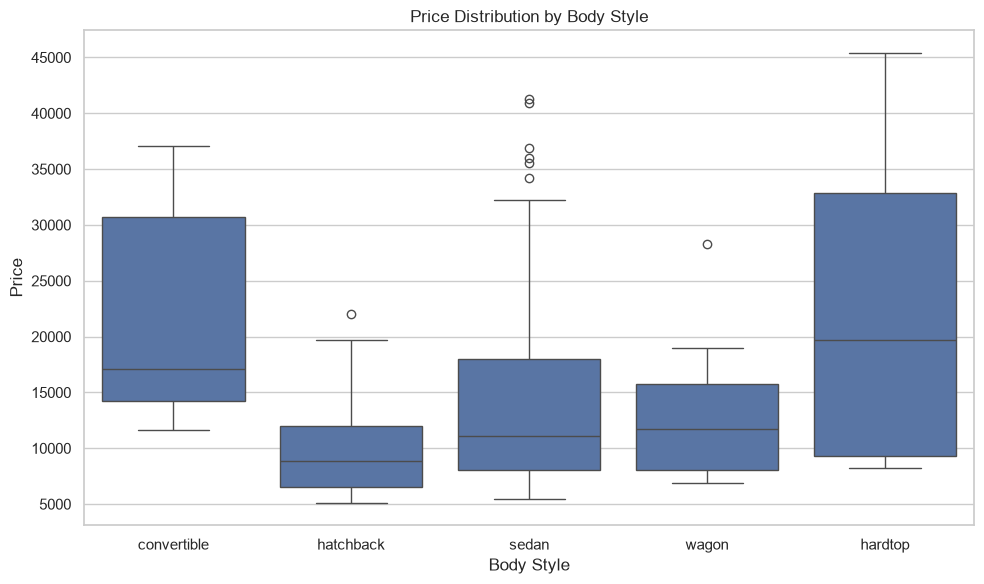

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="body-style",
    y="price"
)

plt.title("Price Distribution by Body Style")
plt.xlabel("Body Style")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

In [18]:
drive_price = (
    df.groupby("drive-wheels")["price"]
      .mean()
      .sort_values(ascending=False)
)

print(drive_price)

drive-wheels
rwd    19655.539474
4wd    10436.444444
fwd     9365.700000
Name: price, dtype: float64


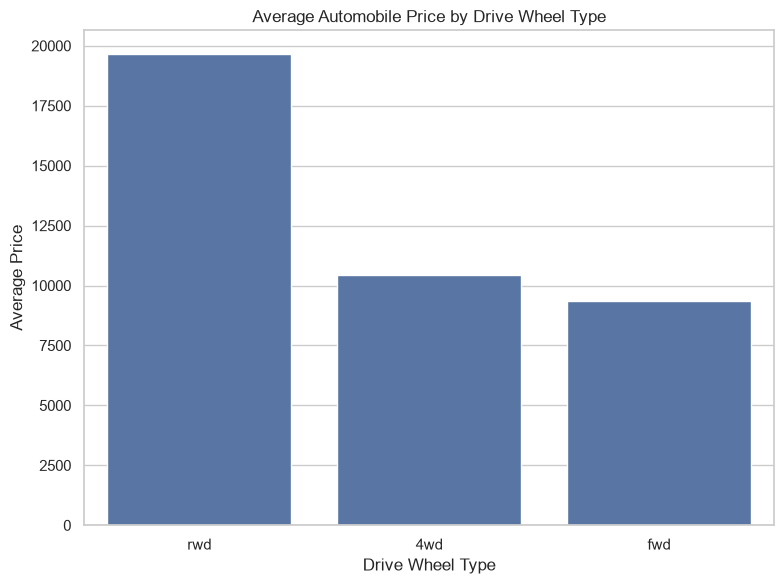

In [19]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=drive_price.index,
    y=drive_price.values
)

plt.title("Average Automobile Price by Drive Wheel Type")
plt.xlabel("Drive Wheel Type")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

In [ ]:
### Drive Wheel Findings

RWD vehicles have the highest average price at approximately 19,655.54.

FWD vehicles are the most common drive configuration, with 120 vehicles,
while RWD has 76 vehicles and 4WD has 9 vehicles.

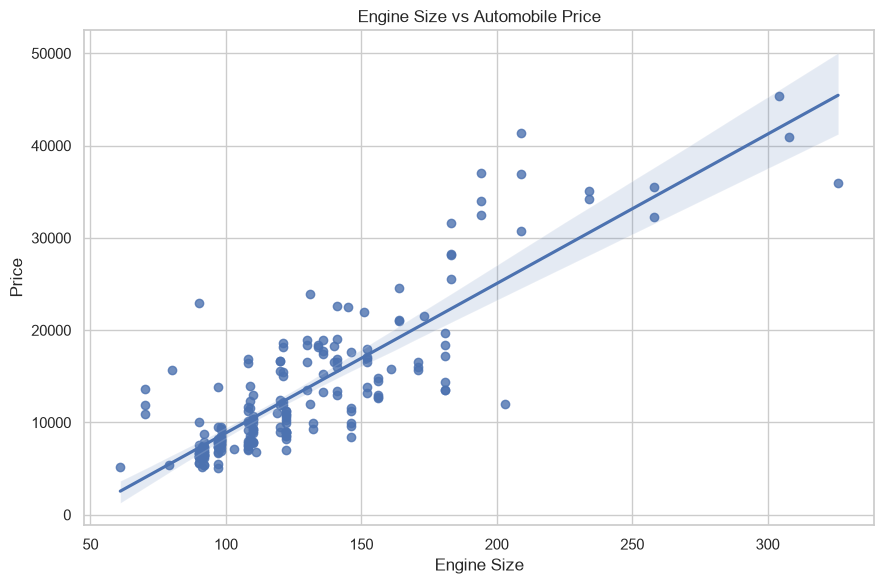

In [20]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="engine-size",
    y="price"
)

plt.title("Engine Size vs Automobile Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

In [ ]:
### Engine Size vs Price

Engine size has the strongest numerical relationship with price
(r = 0.853). The regression plot shows a clear positive trend, indicating
that larger-engine vehicles generally have higher prices in this dataset.

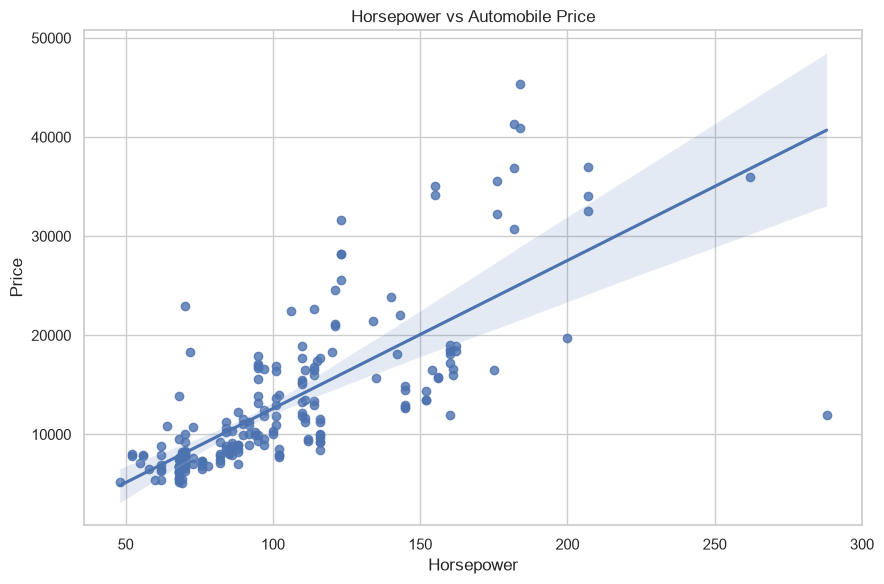

In [21]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="horsepower",
    y="price"
)

plt.title("Horsepower vs Automobile Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

In [ ]:
### Horsepower vs Price

Horsepower has a strong positive relationship with price (r = 0.747),
indicating that higher-powered vehicles tend to have higher prices.

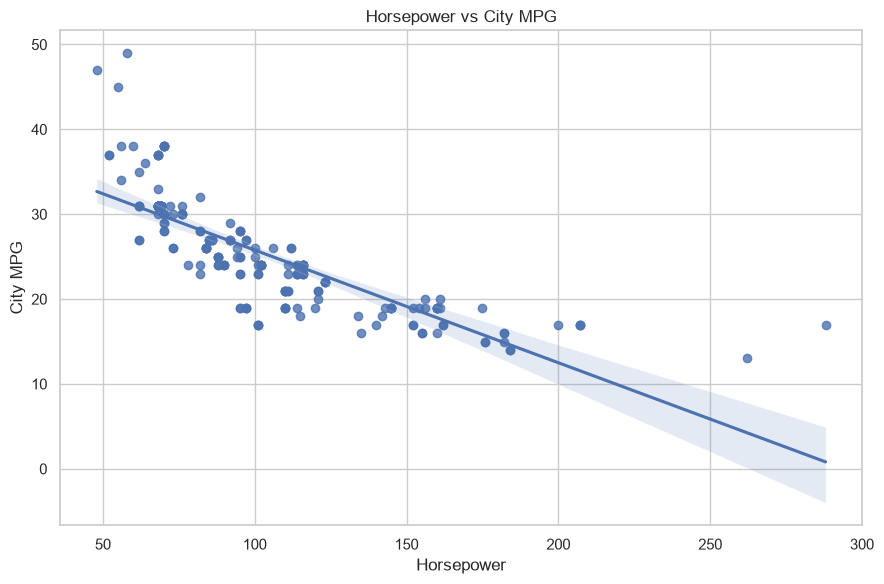

In [22]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="horsepower",
    y="city-mpg"
)

plt.title("Horsepower vs City MPG")
plt.xlabel("Horsepower")
plt.ylabel("City MPG")

plt.tight_layout()
plt.show()

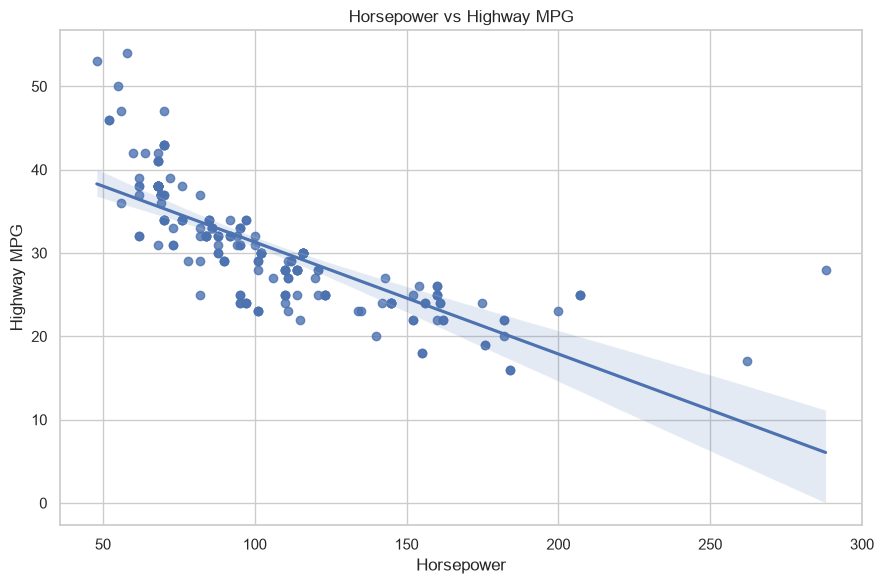

In [23]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="horsepower",
    y="highway-mpg"
)

plt.title("Horsepower vs Highway MPG")
plt.xlabel("Horsepower")
plt.ylabel("Highway MPG")

plt.tight_layout()
plt.show()

In [ ]:
### Performance vs Fuel Efficiency

Horsepower has a strong negative relationship with fuel efficiency.

- Horsepower vs City MPG: r = -0.802
- Horsepower vs Highway MPG: r = -0.771

This indicates that higher-horsepower vehicles tend to have lower MPG
values in this dataset.

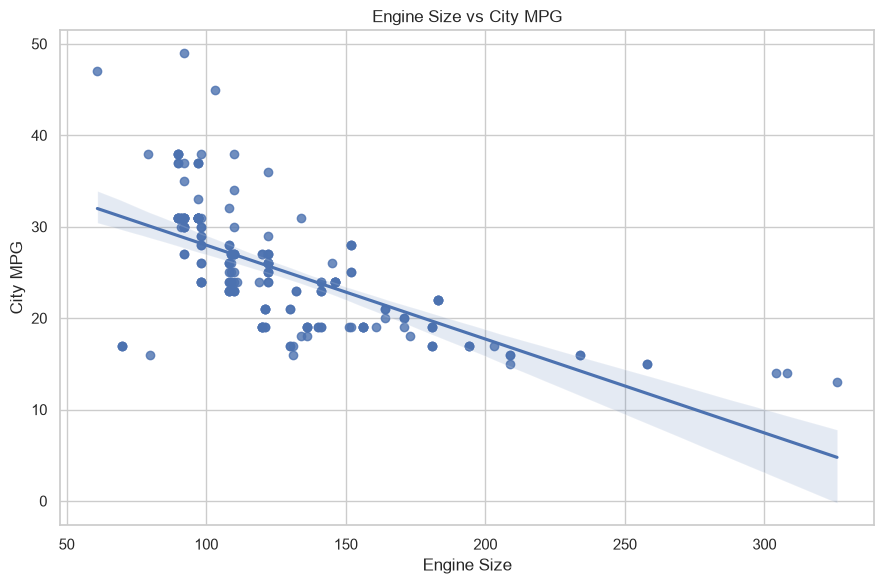

In [24]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="engine-size",
    y="city-mpg"
)

plt.title("Engine Size vs City MPG")
plt.xlabel("Engine Size")
plt.ylabel("City MPG")

plt.tight_layout()
plt.show()

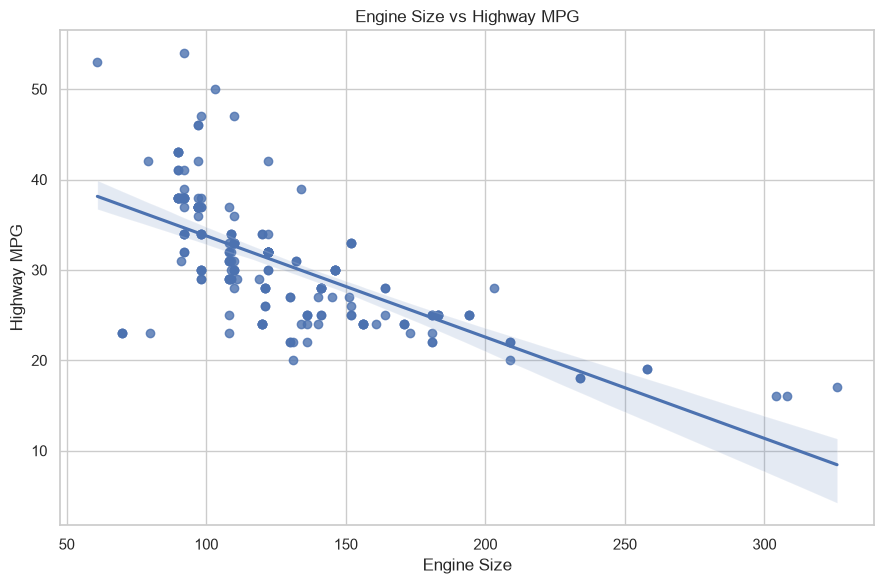

In [25]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="engine-size",
    y="highway-mpg"
)

plt.title("Engine Size vs Highway MPG")
plt.xlabel("Engine Size")
plt.ylabel("Highway MPG")

plt.tight_layout()
plt.show()

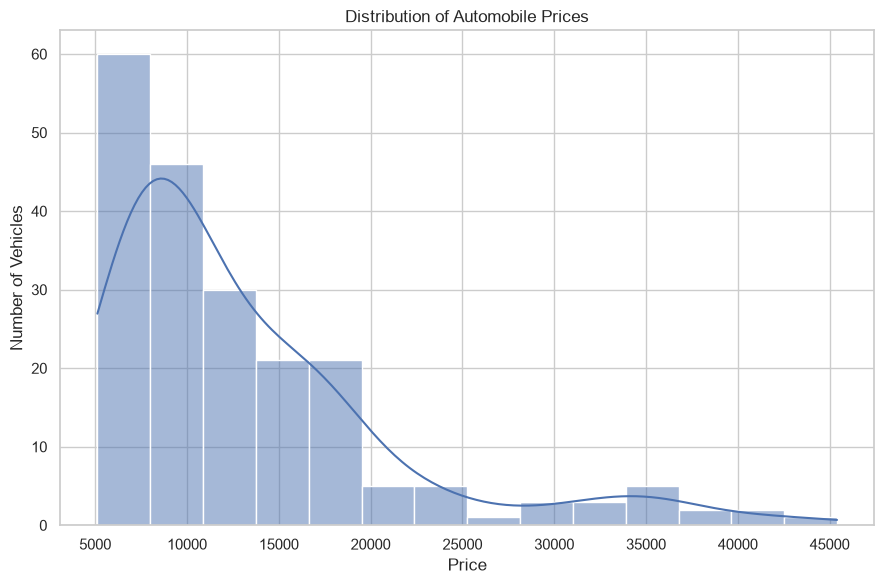

In [26]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="price",
    kde=True
)

plt.title("Distribution of Automobile Prices")
plt.xlabel("Price")
plt.ylabel("Number of Vehicles")

plt.tight_layout()
plt.show()

In [27]:
top_10_expensive = df[
    ["make", "body-style", "engine-size", "horsepower", "price"]
].sort_values(
    by="price",
    ascending=False
).head(10)

top_10_expensive

,make,body-style,engine-size,horsepower,price
74,mercedes-benz,hardtop,304,184.0,45400
16,bmw,sedan,209,182.0,41315
73,mercedes-benz,sedan,308,184.0,40960
128,porsche,convertible,194,207.0,37028
17,bmw,sedan,209,182.0,36880
49,jaguar,sedan,326,262.0,36000
48,jaguar,sedan,258,176.0,35550
72,mercedes-benz,convertible,234,155.0,35056
71,mercedes-benz,sedan,234,155.0,34184
127,porsche,hardtop,194,207.0,34028


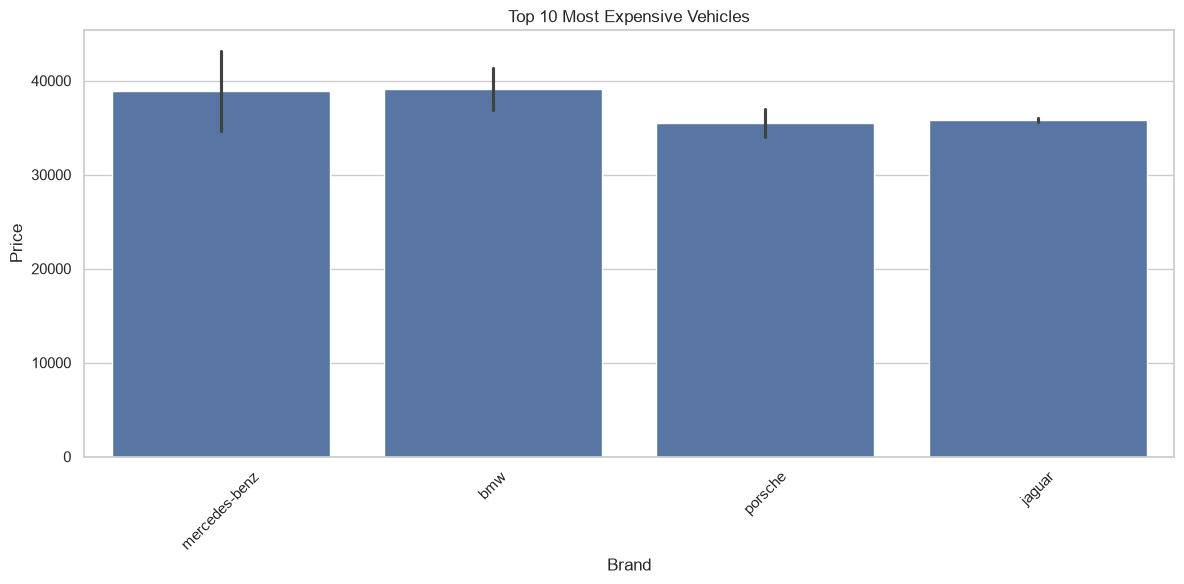

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_expensive,
    x="make",
    y="price"
)

plt.title("Top 10 Most Expensive Vehicles")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

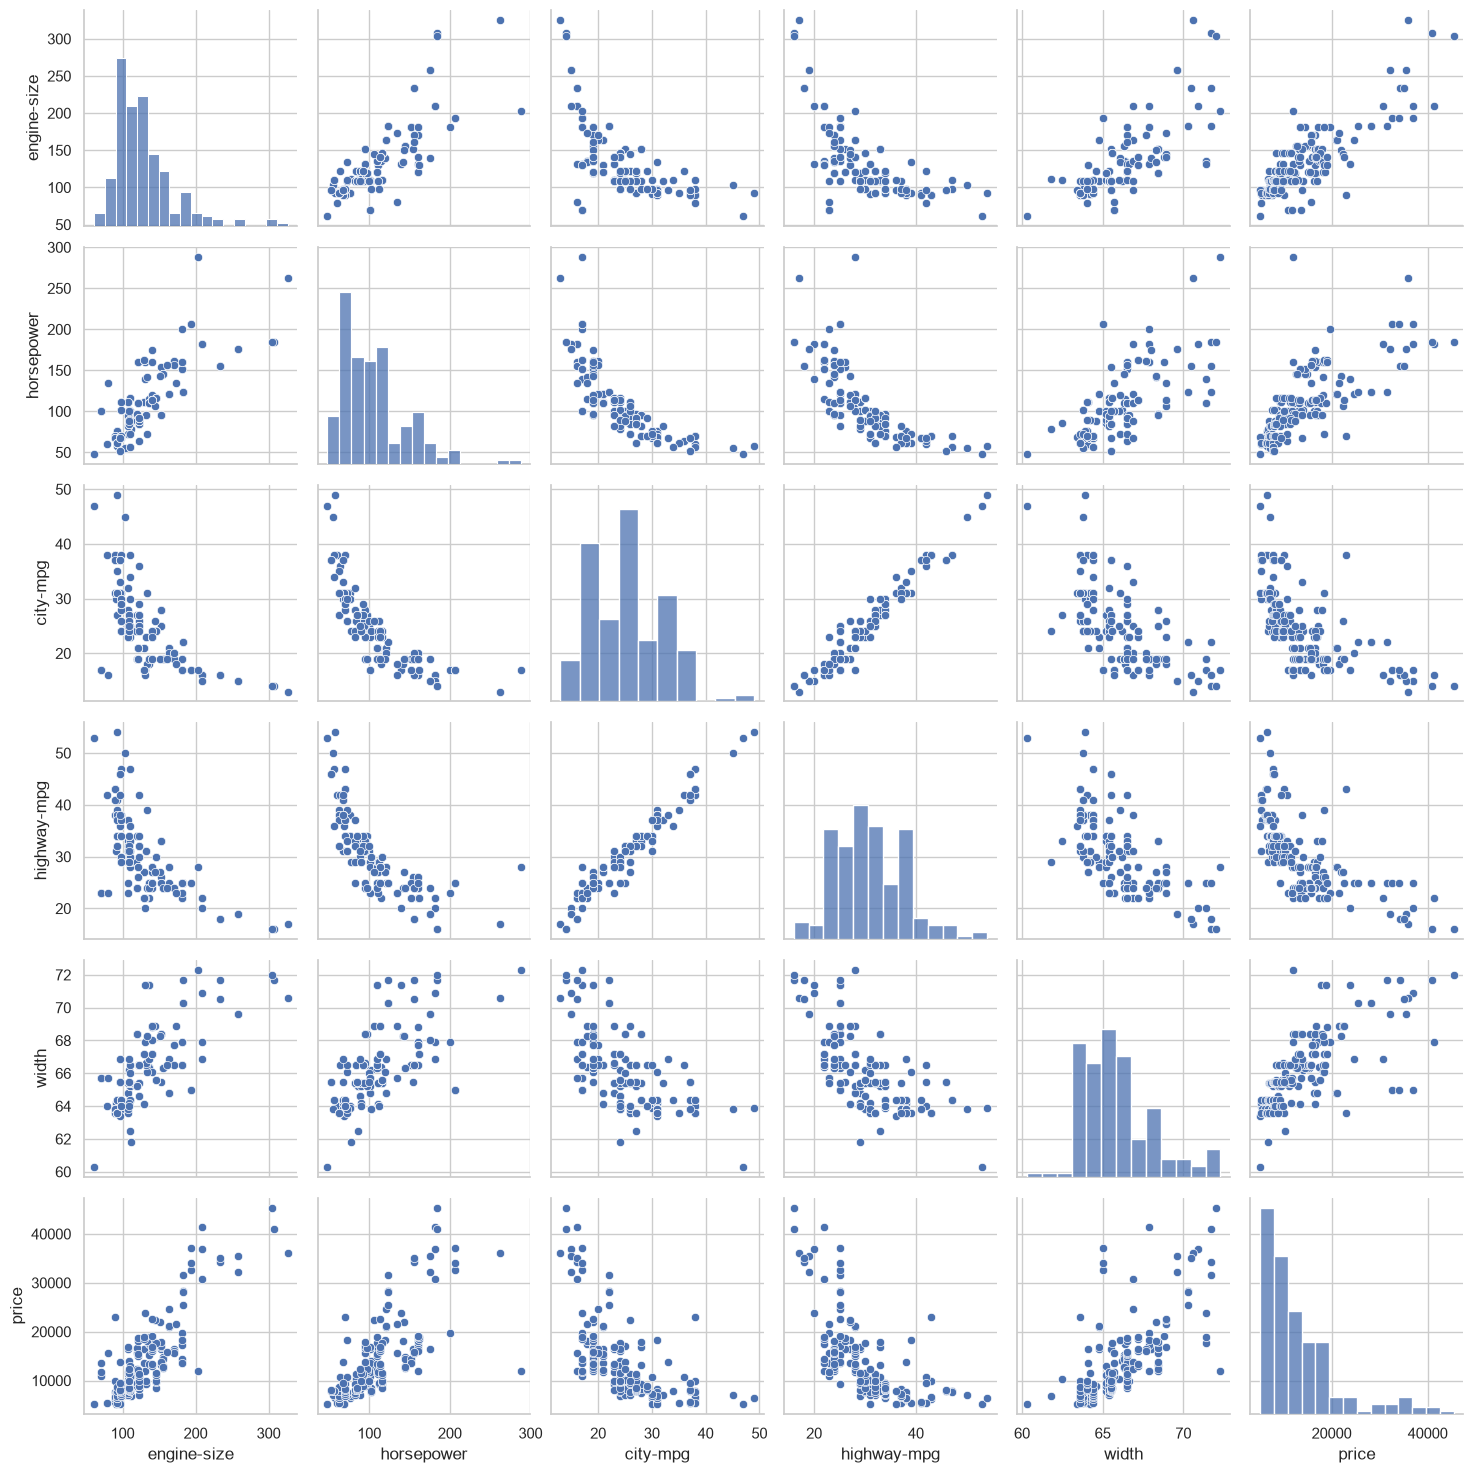

In [29]:
pairplot_data = df[
    [
        "engine-size",
        "horsepower",
        "city-mpg",
        "highway-mpg",
        "width",
        "price"
    ]
]

sns.pairplot(
    pairplot_data,
    diag_kind="hist"
)

plt.show()

In [ ]:
# Final Insights

## Key Findings

1. Engine size has the strongest positive relationship with automobile
   price (r = 0.853).

2. Horsepower has a strong positive relationship with price (r = 0.747).

3. Vehicle width is also strongly associated with price (r = 0.718).

4. City MPG and highway MPG have negative relationships with price.

5. Horsepower has a strong negative relationship with fuel efficiency:
   - City MPG: r = -0.802
   - Highway MPG: r = -0.771

6. Jaguar has the highest average price among the automobile brands in
   the dataset, while Chevrolet has the lowest.

7. Hardtop vehicles have the highest average price among body styles.

8. RWD vehicles have the highest average price among drive-wheel types.

9. Diesel vehicles have higher average MPG and higher average price than
   gas vehicles in this dataset.

10. The most expensive vehicle in the dataset is a Mercedes-Benz hardtop
    priced at 45,400.

In [ ]:
# Conclusion

This project analyzed 205 automobile records using Python, Pandas,
Matplotlib, and Seaborn.

The analysis identified important relationships between automobile
characteristics, pricing, performance, and fuel efficiency. Engine size,
horsepower, and vehicle width showed strong positive relationships with
price, while MPG measures showed negative relationships.

The analysis also demonstrated substantial differences in average price
across brands, body styles, fuel types, and drive-wheel configurations.

Overall, the project demonstrates the use of data cleaning, exploratory
data analysis, statistical correlation, and data visualization to convert
raw automobile data into meaningful business insights.